In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [25]:
# Load your data
abund_mass = pd.read_csv(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\data\abundance_biomass.csv")
sieve = pd.read_csv(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\data\sieve.csv")
toc = pd.read_csv(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\data\toc.csv")

In [26]:
# Calculate organic matter lost (this is second step)
toc["organic_matter"] = toc["dry_weight"] - toc["ash_weight"]
toc["toc_percent"] = (toc["organic_matter"] / toc["dry_weight"]) * 100 * 0.58

# Group by site to get mean and standard deviation
grouped = toc.groupby(["site","replicate","sample", "month"]).agg(toc=('toc_percent', 'mean')).reset_index()

In [29]:
# Preprocessing: Aggregate abundance & biomass per replicate/site/sample
summary = abund_mass.groupby(["site","replicate","sample", "month"]).agg(
    abundance=('prawn_id','count'),
    biomass=('dry_weight','mean'),
    length=('total_length','mean'),
    carapace=('carapace','mean')).reset_index()

In [30]:
# Merge sediment + TOC
sediment = pd.merge(sieve, grouped, on=["site","replicate","sample", "month"], how="left")

# Merge all into one dataset
merged = pd.merge(summary, sediment, on=["site","replicate","sample", "month"], how="left")

In [32]:
X2 = merged.drop(["site","replicate","sample", "month"], axis=1).fillna(0)
X2_scaled = StandardScaler().fit_transform(X2)

# PCA
pca = PCA()
pca_result2 = pca.fit_transform(X2_scaled)

In [33]:
# Variance explained
pca_var_percent = [round(x*100, 1) for x in pca.explained_variance_ratio_]

# Scores dataframe
scores_df = pd.DataFrame(pca_result2, columns=[f"PC{i+1}" for i in range(pca_result2.shape[1])], index=merged.index)
scores_df[list(merged.columns)] = merged

# Loadings dataframe
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                        index=merged.drop(["site","replicate","sample","month"], axis=1).columns)
loadings = loadings.reset_index().rename(columns={"index": "Variable"})

# Scale factor to make arrows visible
scale_factor = 3  
loadings["PC1"] *= scale_factor
loadings["PC2"] *= scale_factor

# Settings
site_col = "site"
label_points = True
label_vars = True
title = "PCA Biplot: Abundance, Biomass & Sediment"

In [34]:
def clean_var_name(name):
    if name.startswith("sieve_"):
        if "mm" in name:  # e.g., sieve_2mm → 2000µm
            value = name.replace("sieve_", "").replace("mm", "")
            return str(int(float(value) * 1000)) + "µm"
        elif "um" in name:  # e.g., sieve_500um → 500µm
            return name.replace("sieve_", "").replace("um", "µm")
        elif "pan" in name:  # handle sieve_pan separately
            return "Pan"
    return name  # leave other names unchanged

# Apply
loadings["Variable"] = loadings["Variable"].apply(clean_var_name)

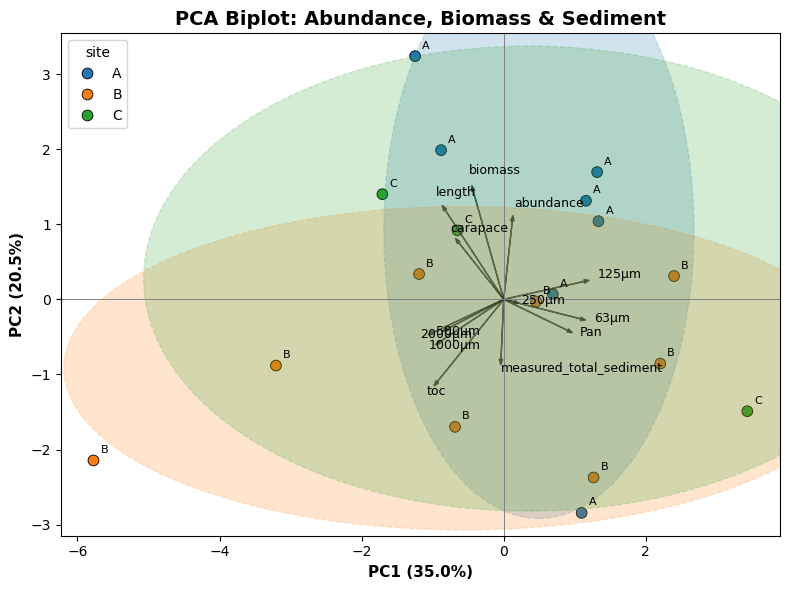

In [40]:
# Plot
plt.figure(figsize=(8, 6))

# Scatter plot of sites
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=site_col, s=60, edgecolor="black")

# Add site labels
if label_points:
    for i, row in scores_df.iterrows():
        plt.text(row["PC1"]+0.1, row["PC2"]+0.1, str(row[site_col]), fontsize=8)

# Arrows for loadings
for _, row in loadings.iterrows():
    plt.arrow(0, 0, row["PC1"], row["PC2"], 
              color="black", alpha=0.7, head_width=0.05, length_includes_head=True)
    if label_vars:
        plt.text(row["PC1"]*1.1, row["PC2"]*1.1, row["Variable"], color="black", fontsize=9)

# Labels & theme
plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=11, fontweight="bold")
plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=11, fontweight="bold")
if title:
    plt.title(title, fontsize=14, fontweight="bold")
plt.axhline(0, color="grey", linewidth=0.7)
plt.axvline(0, color="grey", linewidth=0.7)

# Get the color palette used by seaborn
palette = sns.color_palette(n_colors=scores_df[site_col].nunique())
site_colors = dict(zip(scores_df[site_col].unique(), palette))

for site, group in scores_df.groupby(site_col):
    # Transparent ellipse per site
    ellipse = mpatches.Ellipse(
        (group["PC1"].mean(), group["PC2"].mean()),
        width=group["PC1"].std()*4,
        height=group["PC2"].std()*4,
        facecolor=site_colors[site],   # match site color
        edgecolor=site_colors[site],
        alpha=0.2,                     # transparency
        linestyle="--",
        linewidth=1
    )
    plt.gca().add_patch(ellipse)
    
plt.grid(False)
plt.tight_layout()
plt.savefig(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\fig\PCA_ellipse.png", dpi=500)
plt.show()

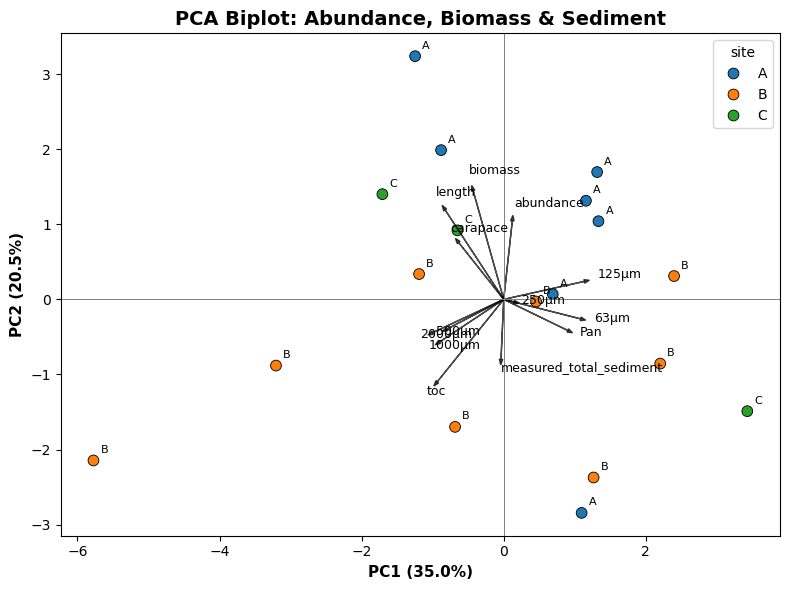

In [41]:
# Plot
plt.figure(figsize=(8, 6))

# Scatter plot of sites
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=site_col, s=60, edgecolor="black")

# Add site labels
if label_points:
    for i, row in scores_df.iterrows():
        plt.text(row["PC1"]+0.1, row["PC2"]+0.1, str(row[site_col]), fontsize=8)

# Arrows for loadings
for _, row in loadings.iterrows():
    plt.arrow(0, 0, row["PC1"], row["PC2"], 
              color="black", alpha=0.7, head_width=0.05, length_includes_head=True)
    if label_vars:
        plt.text(row["PC1"]*1.1, row["PC2"]*1.1, row["Variable"], color="black", fontsize=9)

# Labels & theme
plt.xlabel(f"PC1 ({pca_var_percent[0]}%)", fontsize=11, fontweight="bold")
plt.ylabel(f"PC2 ({pca_var_percent[1]}%)", fontsize=11, fontweight="bold")
if title:
    plt.title(title, fontsize=14, fontweight="bold")
plt.axhline(0, color="grey", linewidth=0.7)
plt.axvline(0, color="grey", linewidth=0.7)
    
plt.grid(False)
plt.tight_layout()
plt.savefig(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\fig\PCA.png", dpi=500)
plt.show()

In [42]:
loadings

,Variable,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,abundance,0.129717,1.120216,0.078300,0.416615,0.595771,-0.040726,0.497783,0.112902,0.087349,0.017219,0.214404,-0.025856,0.085440
1,biomass,-0.451023,1.517389,-0.072791,0.134492,0.049392,0.397827,-0.427513,0.379526,-0.400653,-0.062915,-0.118383,0.119827,-0.133467
2,length,-0.866712,1.252687,0.007160,0.057229,-0.297612,0.175985,-0.114153,-0.277067,0.434043,0.520936,0.203077,-0.096628,0.138434
3,carapace,-0.681060,0.813153,-0.262130,0.129296,-0.560272,-0.229113,0.401181,0.210657,0.115103,-0.435607,-0.109480,0.050313,-0.018014
4,2000µm,-1.067327,-0.473398,-0.324142,0.187277,0.212835,-0.004110,-0.167363,-0.105053,-0.036045,-0.132040,-0.314236,-0.315659,0.637888
5,1000µm,-0.965460,-0.606441,-0.377322,0.061857,0.207506,-0.093318,-0.177149,-0.039295,0.187137,-0.058105,0.310858,0.696652,-0.065761
6,500µm,-0.864560,-0.428447,0.361126,0.230529,-0.152748,0.385032,0.291983,-0.483392,-0.378846,-0.126777,-0.018665,0.247516,0.035846
7,250µm,0.218551,-0.052585,0.610717,0.045571,-0.101214,-0.040658,-0.198894,0.335492,0.285772,-0.182016,-0.000826,0.303801,0.498228
8,125µm,1.206306,0.254977,-0.173561,0.286755,-0.139000,-0.230897,0.056195,-0.092440,-0.185136,0.443453,-0.445843,0.413493,0.183638
9,63µm,1.154702,-0.276740,-0.254215,0.188816,-0.276466,0.139861,-0.047692,0.048989,-0.280193,-0.052595,0.658118,-0.102112,0.342893


In [43]:
pca_var_percent

[np.float64(35.0),
 np.float64(20.5),
 np.float64(19.0),
 np.float64(9.3),
 np.float64(7.1),
 np.float64(4.4),
 np.float64(1.9),
 np.float64(1.2),
 np.float64(0.8),
 np.float64(0.4),
 np.float64(0.2),
 np.float64(0.1),
 np.float64(0.0)]

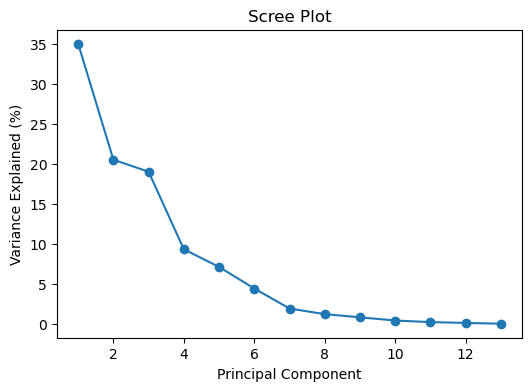

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1, len(pca_var_percent)+1), pca_var_percent, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("Scree Plot")
plt.show()


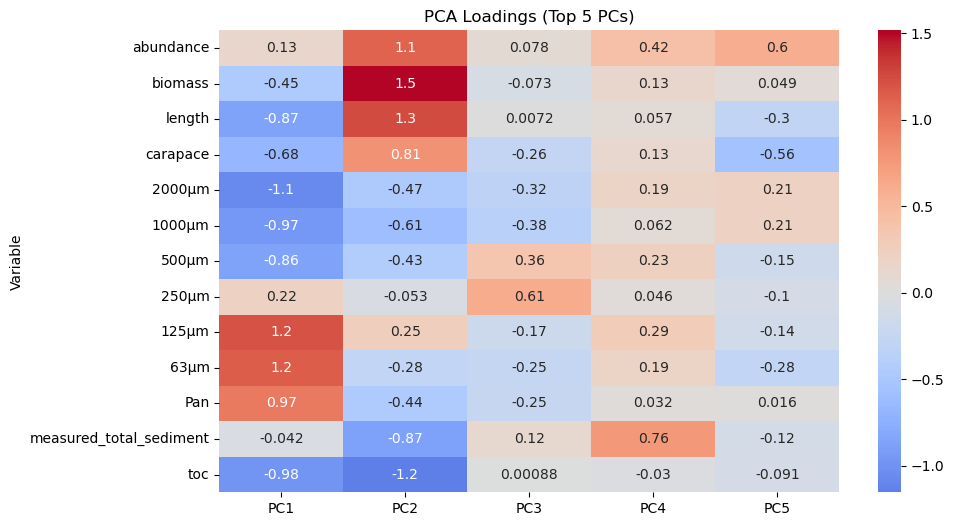

In [45]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(loadings.set_index("Variable").iloc[:,:5], annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loadings (Top 5 PCs)")
plt.show()
